# Projek Final
*   Ingla Finda (2103113595)


In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


# Library

In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import re
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud, STOPWORDS

# **Data Preparation**

## **Data Scrapping**

In [3]:
from google_play_scraper import Sort, reviews

result, continuation_token = reviews(
    'com.apps.MyXL',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000,
    filter_score_with=None
)


In [4]:
data = pd.DataFrame(np.array(result),columns=['review'])
data = data.join(pd.DataFrame(data.pop('review').tolist()))
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ac6ebb28-fc55-41ac-88aa-ef4df0562523,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",2,0,9.5.0,2026-09-22 08:54:36,"Hi Kak, mohon maaf atas kendala yang terjadi. ...",2026-09-22 09:00:09,9.5.0
1,cd8a80c7-851e-4cf6-93ed-b2f2882c059a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Modus doang!!,1,1,None,2026-09-22 08:44:21,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-08-06 07:00:37,None
2,f31e1b60-c38d-4b2b-aea5-26ffeae04ede,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,setelah 1 tahun pemakaian jaringan jelek lemot,1,0,9.5.0,2026-09-22 08:43:44,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-09-22 09:00:12,9.5.0
3,aeb44611-c03d-45b8-a7c3-a9f9d3d4ae51,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saat complain ke Maya atau agent tidak membant...,1,0,9.5.0,2026-09-22 08:23:39,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-09-22 09:00:14,9.5.0
4,48b55c23-2123-4486-9a29-6c97b3eb3564,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong perbaiki sinyalnya setiap lagi main gam...,1,0,9.5.0,2026-09-22 08:07:14,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-09-22 09:00:16,9.5.0


In [5]:
len(data.index) #Jumlah observasi data scrapping

50000

In [6]:
#Urutkan data dari yang terbaru
new_df = data[['userName', 'score','at', 'content']]
sorted_df = new_df.sort_values(by='at', ascending=False)
sorted_df.head()

,userName,score,at,content
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ..."
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...


In [7]:
my_df = sorted_df[['userName', 'score','at', 'content']]
#Ganti tipe data 'at'
my_df['at'] = pd.to_datetime(my_df['at'])
my_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   userName  50000 non-null  object        
 1   score     50000 non-null  int64         
 2   at        50000 non-null  datetime64[ns]
 3   content   50000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.9+ MB


In [8]:
#Ulasan untuk tahun 2026
start_date = '2026-01-01 00:00:00'
end_date = '2026-10-31 23:59:00'
my_df = my_df[(my_df['at'] >= start_date) & (my_df['at'] <= end_date)]
my_df

,userName,score,at,content
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ..."
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...
...,...,...,...,...
39276,Pengguna Google,1,2026-01-01 01:15:53,"aplikasi sering eror,harga paket mahal gak ngo..."
39277,Pengguna Google,1,2026-01-01 01:10:12,"Paket data tidak masuk secara utuh , tidak ses..."
39278,Pengguna Google,2,2026-01-01 00:41:44,"sinyal suka hilang sendiri, kalo mau maketin k..."
39279,Pengguna Google,1,2026-01-01 00:40:05,Aplikasinya sering tidak bisa di buka padahal ...


## **Pelabelan**

In [9]:
def pelabelan(score):
  if score <= 3:
    return 'Negatif'
  elif score >= 3 :
    return 'Positif'
my_df['Label'] = my_df ['score'].apply(pelabelan)
my_df.head(50)

,userName,score,at,content,Label
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif
5,Pengguna Google,4,2026-09-22 07:57:33,"min, tolong lah kasih paket combo 30 hari prom...",Positif
6,Pengguna Google,1,2026-09-22 07:50:25,setiap x srh tggu. tak bayr mahal2 selalu tida...,Negatif
7,Pengguna Google,5,2026-09-22 07:49:46,Sudah Oke Tingkatkan Terus k Kualitas Produk L...,Positif
8,Pengguna Google,1,2026-09-22 07:11:54,woe bisa buat aplikasi GK sih kalau buat beli ...,Negatif
9,Pengguna Google,2,2026-09-22 07:00:19,tolong kalo harga paket data nya jangan di nai...,Negatif


In [11]:
my_df.to_csv("datascrap.csv", index = False)  #Save file as CSV

## **Data Prepocesing**
data cleaning

In [12]:
import pandas as pd
pd.set_option('display.max_columns', None)
my_df = pd.read_csv('/content/datascrap.csv')
my_df.head(5)

,userName,score,at,content,Label
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif


In [13]:
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39281 entries, 0 to 39280
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  39281 non-null  object
 1   score     39281 non-null  int64 
 2   at        39281 non-null  object
 3   content   39281 non-null  object
 4   Label     39281 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB


In [14]:
#pemeriksaan data missing
my_df.isna().any()

,0
userName,False
score,False
at,False
content,False
Label,False


In [15]:
my_df.describe()

,score
count,39281.000000
mean,2.168708
std,1.605117
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,5.000000


In [16]:
#Pemeriksaan data missing
my_df.isnull().sum()

,0
userName,0
score,0
at,0
content,0
Label,0


1. Handling Missing value-Ignore tuple

In [ ]:
my_df.dropna(subset=['Label'],inplace = True)

In [ ]:
my_df.isnull().sum()

,0
userName,0
score,0
at,0
content,0
Label,0


In [ ]:
my_df.head(5)

,userName,score,at,content,Label
0,Pengguna Google,5,2026-08-15 08:17:36,Bagus,Positif
1,Pengguna Google,5,2026-08-15 08:14:12,xl sangat menbantu,Positif
2,Pengguna Google,5,2026-08-15 08:05:09,untuk pemebelian paket data ko mahal tidak ada...,Positif
3,Pengguna Google,1,2026-08-15 08:04:01,sangat tidak membantu ketika jaringan wifi ber...,Negatif
4,Pengguna Google,1,2026-08-15 08:00:17,sinyal sering lemah padahal posisi di kota bat...,Negatif


In [17]:
my_df.to_csv("MyXLpreprocessing.csv", index = False)

## **Text PreProcessing**

In [18]:
df = pd.read_csv('/content/MyXLpreprocessing.csv')
df.head(5)

,userName,score,at,content,Label
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif


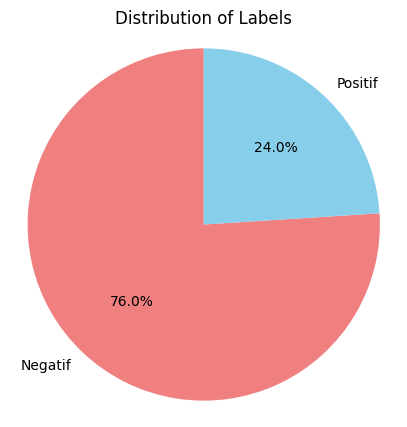

In [20]:
# Count the occurrences of each label
label_counts = df['Label'].value_counts()

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral','skyblue'])
plt.title('Distribution of Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### **Case Folding**
Proses case folding adalah proses mengubah seluruh huruf menjadi huruf kecil. Pada proses ini karakter-karakter 'A'-'Z' yang terdapat pada data diubah kedalam karakter 'a'-'z'.

In [21]:
def  clean_text(df, text_field, new_text_field_name):
    my_df[new_text_field_name] = my_df[text_field].str.lower()
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", "", elem))
    # remove numbers
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    return my_df

In [23]:
my_df['text_clean'] = my_df['content'].str.lower()
my_df['text_clean']
data_clean = clean_text(my_df, 'content', 'text_clean')
data_clean.head(10)

,userName,score,at,content,Label,text_clean
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...
5,Pengguna Google,4,2026-09-22 07:57:33,"min, tolong lah kasih paket combo 30 hari prom...",Positif,min tolong lah kasih paket combo hari promo y...
6,Pengguna Google,1,2026-09-22 07:50:25,setiap x srh tggu. tak bayr mahal2 selalu tida...,Negatif,setiap x srh tggu tak bayr mahal selalu tidak ...
7,Pengguna Google,5,2026-09-22 07:49:46,Sudah Oke Tingkatkan Terus k Kualitas Produk L...,Positif,sudah oke tingkatkan terus k kualitas produk l...
8,Pengguna Google,1,2026-09-22 07:11:54,woe bisa buat aplikasi GK sih kalau buat beli ...,Negatif,woe bisa buat aplikasi gk sih kalau buat beli ...
9,Pengguna Google,2,2026-09-22 07:00:19,tolong kalo harga paket data nya jangan di nai...,Negatif,tolong kalo harga paket data nya jangan di nai...


### **Stopword Removal**
Stopword adalah kata umum yang biasanya muncul dalam jumlah besar dan dianggap tidak memiliki makna. Contoh stopword dalam bahasa Indonesia adalah “yang”, “dan”, “di”, “dari”, dll. Makna di balik penggunaan stopword yaitu dengan menghapus kata-kata yang memiliki informasi rendah dari sebuah teks, kita dapat fokus pada kata-kata penting sebagai gantinya.

In [24]:
import nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('indonesian')
data_clean['text_StopWord'] = data_clean['text_clean'].apply(lambda x:' '.join([word for word in x.split() if word not in (stop)]))
data_clean.head(50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,userName,score,at,content,Label,text_clean,text_StopWord
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...,kuota ml ribu dihilangin ampas kali ni apk
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang,modus doang
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...,complain maya agent membantu solusi
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...,tolong perbaiki sinyalnya main game sinyal ilang
5,Pengguna Google,4,2026-09-22 07:57:33,"min, tolong lah kasih paket combo 30 hari prom...",Positif,min tolong lah kasih paket combo hari promo y...,min tolong kasih paket combo promo yg murah mi...
6,Pengguna Google,1,2026-09-22 07:50:25,setiap x srh tggu. tak bayr mahal2 selalu tida...,Negatif,setiap x srh tggu tak bayr mahal selalu tidak ...,x srh tggu bayr mahal internet kmrn firstmedia...
7,Pengguna Google,5,2026-09-22 07:49:46,Sudah Oke Tingkatkan Terus k Kualitas Produk L...,Positif,sudah oke tingkatkan terus k kualitas produk l...,oke tingkatkan k kualitas produk layanan pelan...
8,Pengguna Google,1,2026-09-22 07:11:54,woe bisa buat aplikasi GK sih kalau buat beli ...,Negatif,woe bisa buat aplikasi gk sih kalau buat beli ...,woe aplikasi gk sih beli kota top up gk gimana...
9,Pengguna Google,2,2026-09-22 07:00:19,tolong kalo harga paket data nya jangan di nai...,Negatif,tolong kalo harga paket data nya jangan di nai...,tolong kalo harga paket data nya naikin muluu ...


### Normalisasi Kata

In [26]:
# Install google_trans_new as an alternative to googletrans
try:
    import google_trans_new
except ImportError:
    !pip install google_trans_new

# Import the translator from the new library
from google_trans_new import google_translator

In [27]:
translator = google_translator()

def round_trip_translate(text):
    if not isinstance(text, str) or not text.strip():
        return text # Return original if not string or empty
    try:
        # Translate Indonesian to English
        translated_to_en = translator.translate(text, lang_src='id', lang_tgt='en')
        # Translate English back to Indonesian
        translated_to_id = translator.translate(translated_to_en, lang_src='en', lang_tgt='id')
        return translated_to_id
    except Exception as e:
        print(f"Translation error for text: '{text[:50]}...' Error: {e}")
        return text # Return original text in case of error

# Apply the round-trip translation to the 'text_StopWord' column
data_clean['text_roundtrip_translated'] = data_clean['text_StopWord'].apply(round_trip_translate)

data_clean.head()

Output streaming akan dipotong hingga 5000 baris terakhir.
Translation error for text: 'internetnya buruk...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'kikir aja ni xl...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'tolong fitur kirim xl poin nya update tambahkan fi...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'kartu xl nya emang bagus bonus nya sinyal jelek ba...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'pulsa nya kesedot dpt sms perpanjangan ganti paket...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'bagus...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'diskon nyah mulu gajelas mahal suka error data nya...' Error: 404 (Not Found) from TTS API. Probable cause: Unknown
Translation error for text: 'jaringan s

,userName,score,at,content,Label,text_clean,text_StopWord,text_roundtrip_translated
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...,kuota ml ribu dihilangin ampas kali ni apk,kuota ml ribu dihilangin ampas kali ni apk
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang,modus doang,modus doang
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...,complain maya agent membantu solusi,complain maya agent membantu solusi
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...,tolong perbaiki sinyalnya main game sinyal ilang,tolong perbaiki sinyalnya main game sinyal ilang


### **Tokenizing**
Tokenizing adalah proses pemisahan teks menjadi potongan-potongan yang disebut sebagai token untuk kemudian di analisa. Kata, angka, simbol, tanda baca dan entitas penting lainnya dapat dianggap sebagai token. Didalam NLP, token diartikan sebagai “kata” meskipun tokenize juga dapat dilakukan pada paragraf maupun kalimat

In [28]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize
data_clean['text_tokens'] = data_clean['text_StopWord'].apply(lambda x: word_tokenize(x))
data_clean.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,userName,score,at,content,Label,text_clean,text_StopWord,text_roundtrip_translated,text_tokens
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...,kuota ml ribu dihilangin ampas kali ni apk,kuota ml ribu dihilangin ampas kali ni apk,"[kuota, ml, ribu, dihilangin, ampas, kali, ni,..."
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang,modus doang,modus doang,"[modus, doang]"
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,"[pemakaian, jaringan, jelek, lemot]"
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...,complain maya agent membantu solusi,complain maya agent membantu solusi,"[complain, maya, agent, membantu, solusi]"
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...,tolong perbaiki sinyalnya main game sinyal ilang,tolong perbaiki sinyalnya main game sinyal ilang,"[tolong, perbaiki, sinyalnya, main, game, siny..."


### **Stemming**
Stemming adalah proses pemetaan dan penguraian bentuk dari suatu kata menjadi bentuk kata dasarnya. Untuk melakukan stemming bahasa Indonesia kita dapat menggunakan library Python Sastrawi yang sudah kita siapkan di awal. Library Sastrawi menerapkan Algoritma Nazief dan Adriani dalam melakukan stemming bahasa Indonesia.

In [29]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [30]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [31]:
#-----------------STEMMING -----------------
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}

for document in data_clean['text_tokens']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

# Populate term_dict with stemmed words
for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)

# apply stemmed term to dataframe
def get_stemmed_term(document):
    return [term_dict[term] for term in document]

data_clean['text_steamindo'] = data_clean['text_tokens'].apply(lambda x:' '.join(get_stemmed_term(x)))
data_clean.head()

,userName,score,at,content,Label,text_clean,text_StopWord,text_roundtrip_translated,text_tokens,text_steamindo
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...,kuota ml ribu dihilangin ampas kali ni apk,kuota ml ribu dihilangin ampas kali ni apk,"[kuota, ml, ribu, dihilangin, ampas, kali, ni,...",kuota ml ribu dihilangin ampas kali ni apk
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang,modus doang,modus doang,"[modus, doang]",modus doang
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,"[pemakaian, jaringan, jelek, lemot]",pakai jaring jelek lot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...,complain maya agent membantu solusi,complain maya agent membantu solusi,"[complain, maya, agent, membantu, solusi]",complain maya agent bantu solusi
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...,tolong perbaiki sinyalnya main game sinyal ilang,tolong perbaiki sinyalnya main game sinyal ilang,"[tolong, perbaiki, sinyalnya, main, game, siny...",tolong baik sinyal main game sinyal ilang


In [32]:
data_clean

,userName,score,at,content,Label,text_clean,text_StopWord,text_roundtrip_translated,text_tokens,text_steamindo
0,Pengguna Google,2,2026-09-22 08:54:36,"kuota ML 7hari 9ribu malah dihilangin,, ampas ...",Negatif,kuota ml hari ribu malah dihilangin ampas kali...,kuota ml ribu dihilangin ampas kali ni apk,kuota ml ribu dihilangin ampas kali ni apk,"[kuota, ml, ribu, dihilangin, ampas, kali, ni,...",kuota ml ribu dihilangin ampas kali ni apk
1,Pengguna Google,1,2026-09-22 08:44:21,Modus doang!!,Negatif,modus doang,modus doang,modus doang,"[modus, doang]",modus doang
2,Pengguna Google,1,2026-09-22 08:43:44,setelah 1 tahun pemakaian jaringan jelek lemot,Negatif,setelah tahun pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,pemakaian jaringan jelek lemot,"[pemakaian, jaringan, jelek, lemot]",pakai jaring jelek lot
3,Pengguna Google,1,2026-09-22 08:23:39,saat complain ke Maya atau agent tidak membant...,Negatif,saat complain ke maya atau agent tidak membant...,complain maya agent membantu solusi,complain maya agent membantu solusi,"[complain, maya, agent, membantu, solusi]",complain maya agent bantu solusi
4,Pengguna Google,1,2026-09-22 08:07:14,tolong perbaiki sinyalnya setiap lagi main gam...,Negatif,tolong perbaiki sinyalnya setiap lagi main gam...,tolong perbaiki sinyalnya main game sinyal ilang,tolong perbaiki sinyalnya main game sinyal ilang,"[tolong, perbaiki, sinyalnya, main, game, siny...",tolong baik sinyal main game sinyal ilang
...,...,...,...,...,...,...,...,...,...,...
39276,Pengguna Google,1,2026-01-01 01:15:53,"aplikasi sering eror,harga paket mahal gak ngo...",Negatif,aplikasi sering erorharga paket mahal gak ngot...,aplikasi erorharga paket mahal gak ngotaksinya...,aplikasi erorharga paket mahal gak ngotaksinya...,"[aplikasi, erorharga, paket, mahal, gak, ngota...",aplikasi erorharga paket mahal gak ngotaksinya...
39277,Pengguna Google,1,2026-01-01 01:10:12,"Paket data tidak masuk secara utuh , tidak ses...",Negatif,paket data tidak masuk secara utuh tidak sesu...,paket data masuk utuh sesuai deskripsi paket d...,paket data masuk utuh sesuai deskripsi paket d...,"[paket, data, masuk, utuh, sesuai, deskripsi, ...",paket data masuk utuh sesuai deskripsi paket d...
39278,Pengguna Google,2,2026-01-01 00:41:44,"sinyal suka hilang sendiri, kalo mau maketin k...",Negatif,sinyal suka hilang sendiri kalo mau maketin ku...,sinyal suka hilang kalo maketin kuota pake pul...,sinyal suka hilang kalo maketin kuota pake pul...,"[sinyal, suka, hilang, kalo, maketin, kuota, p...",sinyal suka hilang kalo maketin kuota pake pul...
39279,Pengguna Google,1,2026-01-01 00:40:05,Aplikasinya sering tidak bisa di buka padahal ...,Negatif,aplikasinya sering tidak bisa di buka padahal ...,aplikasinya buka jaringannya bagus plus kuota ...,aplikasinya buka jaringannya bagus plus kuota ...,"[aplikasinya, buka, jaringannya, bagus, plus, ...",aplikasi buka jaring bagus plus kuota nya maha...


In [33]:
data_clean.to_csv('hasil_TextPreProcessing_MyXL.csv', index=False)

In [34]:
import re
def praproses(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)()(?:-)?(?:\)|\(|D|P)',
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))
    return text

<>:4: SyntaxWarning: invalid escape sequence '\)'
<>:6: SyntaxWarning: invalid escape sequence '\W'
<>:4: SyntaxWarning: invalid escape sequence '\)'
<>:6: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_1482/3563271621.py:4: SyntaxWarning: invalid escape sequence '\)'
  emoticons = re.findall('(?::|;|=)()(?:-)?(?:\)|\(|D|P)',
/tmp/ipykernel_1482/3563271621.py:6: SyntaxWarning: invalid escape sequence '\W'
  text = (re.sub('[\W]+', ' ', text.lower()) +


### **Proporsi Label**

Counter({'Negatif': 29859, 'Positif': 9422})


/tmp/ipykernel_1482/2263249156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y,palette=['green', 'blue'])


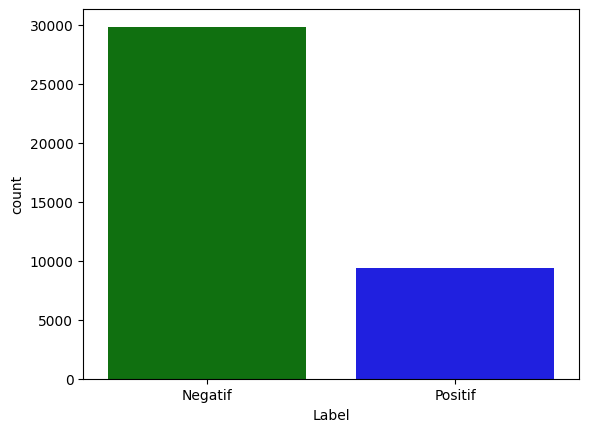

In [35]:
x = data_clean.text_steamindo
y = data_clean.Label

print(Counter(y))
sns.countplot(x=y,palette=['green', 'blue'])
plt.show()

# **Word Cloud**

In [36]:
Positif= " ".join(review for review in data_clean[data_clean['Label'] == 'Positif'].text_steamindo)
Negatif= " ".join(review for review in data_clean[data_clean['Label'] == 'Negatif'].text_steamindo)
stopwords = set(STOPWORDS)
def plot_cloud(wordcloud):
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud)
    plt.axis("off");

## **Wordcloud label posiif**

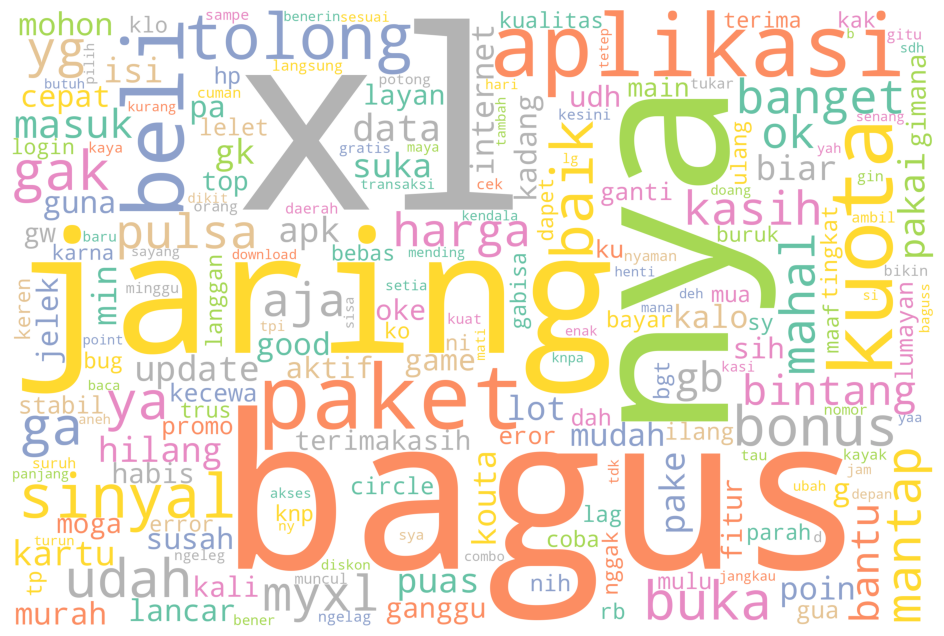

In [37]:
wordcloud1 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='white', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(Positif)
plot_cloud(wordcloud1)

## *Wordcloud Label Negatif*

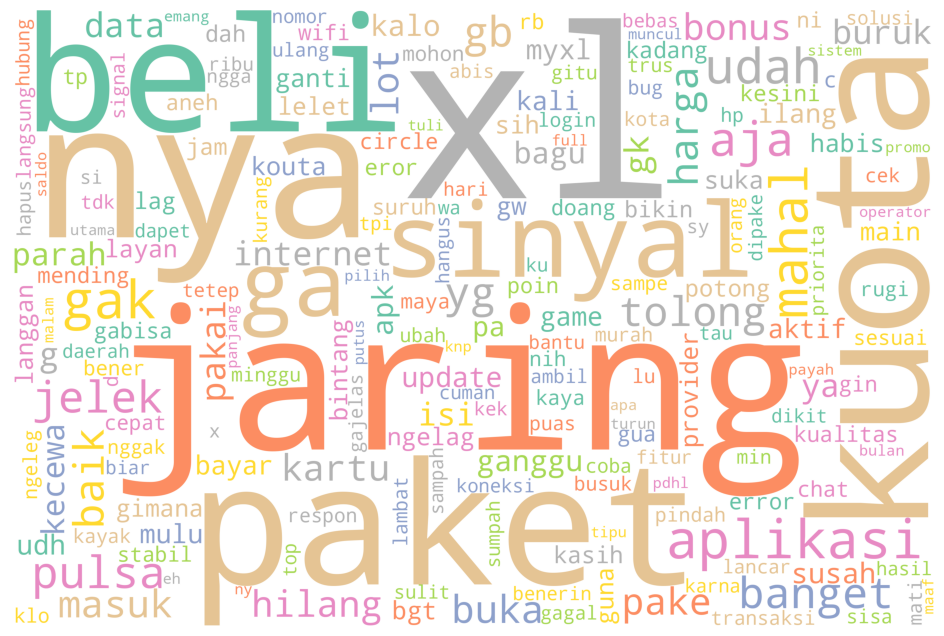

In [38]:
wordcloud1 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='white', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(Negatif)
plot_cloud(wordcloud1)

# **ANALISIS SENTIMEN**

In [39]:
X_train, X_test, y_train, y_test = train_test_split(data_clean['content'], data_clean['Label'],
                                                    test_size = 0.20,
                                                    random_state = 0)

In [40]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

In [41]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(31424,)
(31424,)
(7857,)
(7857,)


In [42]:
vectorizer = CountVectorizer()
vectorizer.fit(X_train)

CountVectorizer()

In [43]:
X_train = vectorizer.transform(X_train)
X_test = vectorizer.transform(X_test)

In [44]:
nb = MultinomialNB()
nb.fit(tfidf_train, y_train)

MultinomialNB()

In [45]:
X_train.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [47]:
y_pred = nb.predict(tfidf_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8532518773068601

In [49]:
clf = MultinomialNB()
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)

print("MultinomialNB Accuracy:", accuracy_score(y_test,predicted))
print("MultinomialNB Precision:", precision_score(y_test,predicted, average="binary", pos_label="Negatif"))
print("MultinomialNB Recall:", recall_score(y_test,predicted, average="binary", pos_label="Negatif"))
print("MultinomialNB f1_score:", f1_score(y_test,predicted, average="binary", pos_label="Negatif"))

print(f'confusion_matrix:\n {confusion_matrix(y_test, predicted)}')
print('====================================================\n')
print(classification_report(y_test, predicted, zero_division=0))

# Load dataset
data_clean = pd.read_csv('hasil_TextPreProcessing_MyXL.csv')

MultinomialNB Accuracy: 0.8621611302023673
MultinomialNB Precision: 0.8745258686087088
MultinomialNB Recall: 0.9574750830564784
MultinomialNB f1_score: 0.9141225913884704
confusion_matrix:
 [[5764  256]
 [ 827 1010]]

              precision    recall  f1-score   support

     Negatif       0.87      0.96      0.91      6020
     Positif       0.80      0.55      0.65      1837

    accuracy                           0.86      7857
   macro avg       0.84      0.75      0.78      7857
weighted avg       0.86      0.86      0.85      7857



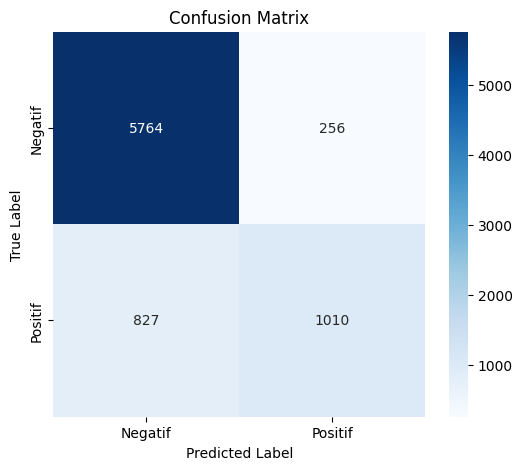

In [50]:
cm = confusion_matrix(y_test, predicted)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()